Laboratorio de Métodos Cuantitativos para la gestión

---
## Recuperatorio del Segundo Parcial




---

Nombre y Apellido: Alexander Ballera



---
Número de registro: 919064


---
Importo Librerías necesarias

In [637]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

Funciones útiles

In [638]:
# Valor máximo de las ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

In [639]:
# Fórmula de Equivalencia
def tasa_equivalente(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

In [640]:
# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

---

# Ejercicio 1

---

Supongamos que una empresa tiene las siguientes funciones:

- Función de Ingreso Marginal (IMg): $$ IMg(q) = 120 - 0.04 \cdot q $$

  donde $q$ es la cantidad producida.

- Función de Costo Marginal (CMg): $$ CMg(q) = 0.002 \cdot q^2 - 0.3 \cdot q + 70 $$

Además, se sabe que el **costo fijo** de la empresa es de **$1500.**

1.  **Recuperar la función de Ingreso Total (I(q))**:  Asume que el ingreso total es cero cuando la cantidad producida es cero ($I(0) = 0$).
2.  **Recuperar la función de Costo Total (C(q))**
3.  **Calcular la función de Beneficio Total (B(q))**
4.  **Encontrar la cantidad óptima (q*)**: Determina la cantidad de producción que maximiza el beneficio. Puedes lograr esto igualando el ingreso marginal al costo marginal ($IMg(q) = CMg(q)$) y resolviendo para $q$. Considera solo valores de $q > 0$.
5.  **Calcular el Beneficio Máximo (B(q*))**
6.  **Visualizar las funciones**: Grafica las funciones de ingreso total, costo total y beneficio total en el mismo gráfico para visualizar el punto de beneficio máximo. Interpretar el gráfico.

### 1.  **Recuperar la función de Ingreso Total (I(q))**:  Asume que el ingreso total es cero cuando la cantidad producida es cero ($I(0) = 0$).

In [641]:
# Paso 1: Defino variables simbólicas
q = sp.symbols('q', positive=True)
q

q

In [642]:
# Paso 2: Defino la función de Ingreso Marginal
IMg = 120.0 - 0.04*q
IMg

120.0 - 0.04*q

In [643]:
# Paso 3: Integro para obtener la función de Ingreso Total con I(0) = 0
# como condición inicial, por lo que no agrego constante de integración (F)
I = sp.integrate(IMg, q)
I = sp.simplify(I)
I

q*(120.0 - 0.02*q)

In [644]:
# Derivo I(q) para validar que sea igual a IMg
sp.diff(I, q).simplify() == IMg  # Deben ser iguales

True

### 2.  **Recuperar la función de Costo Total (C(q))**

In [645]:
# Paso 1: Defino las variables simbólicas: Costo Fijo F
F = sp.symbols('F')
F

F

In [646]:
# Paso 2: Defino la función de Ingreso Marginal
CMg = 0.002*q**2 - 0.3*q + 70.0
CMg = sp.simplify(CMg)
CMg

0.002*q**2 - 0.3*q + 70.0

In [647]:
# Paso 3: Integro la función de Costo Marginal para obtener la función de Costo Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.000666666666666667*q**3 - 0.15*q**2 + 70.0*q

In [648]:
# Paso 4: Sustituyo C0 = F = 1500.00 en la función de Costo Total
C = C.subs(F, 1500)
C

0.000666666666666667*q**3 - 0.15*q**2 + 70.0*q + 1500

### 3.  **Calcular la función de Beneficio Total (B(q))**

In [649]:
B = I - C
B = sp.simplify(B)
B

-0.000666666666666667*q**3 + 0.13*q**2 + 50.0*q - 1500.0

### 4.  **Encontrar la cantidad óptima (q*)**: Determina la cantidad de producción que maximiza el beneficio. Puedes lograr esto igualando el ingreso marginal al costo marginal ($IMg(q) = CMg(q)$) y resolviendo para $q$. Considera solo valores de $q > 0$.

In [650]:
q_opt = round(sp.solve(sp.Eq(IMg, CMg), q)[0])
q_opt.evalf()

236.000000000000

### 5.  **Calcular el Beneficio Máximo (B(q*))**

In [651]:
B_opt = B.subs(q, q_opt)
round(B_opt.evalf(), 2)

8777.64

### 6.  **Visualizar las funciones**: Grafica las funciones de ingreso total, costo total y beneficio total en el mismo gráfico para visualizar el punto de beneficio máximo. Interpretar el gráfico.

In [652]:
# Paso 1: Defino vaiables necesarias
# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_opt))
x_max = x_y_max (x_max, 1.75, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = 45000

# Creo un rango de cantidades producidas
q_grid = np.linspace(0, x_max, 500)

In [653]:
# Paso 2: Convierto las funciones simbólicas a funciones numéricas
I_num = sp.lambdify(q, I, modules=['numpy'])
C_num = sp.lambdify(q, C, modules=['numpy'])
B_num = sp.lambdify(q, B, modules=['numpy'])

In [654]:
# Paso 3: Evalúo las funciones en el rango de cantidades
I_vals = I_num(q_grid)
C_vals = C_num(q_grid)
B_vals = B_num(q_grid)

In [655]:
# Paso 4: Establezco dominio de x y variables

# Variables
I_opt = float(I_num(q_opt))
C_opt = float(C_num(q_opt))
B_opt = float(B_num(q_opt))
q_opt = float(q_opt)
print(f'I_opt: {I_opt:.2f}')
print(f'C_opt: {C_opt:.2f}')
print(f'B_opt: {B_opt:.2f}')
print(f'q_opt: {q_opt}')

I_opt: 27206.08
C_opt: 18428.44
B_opt: 8777.64
q_opt: 236.0


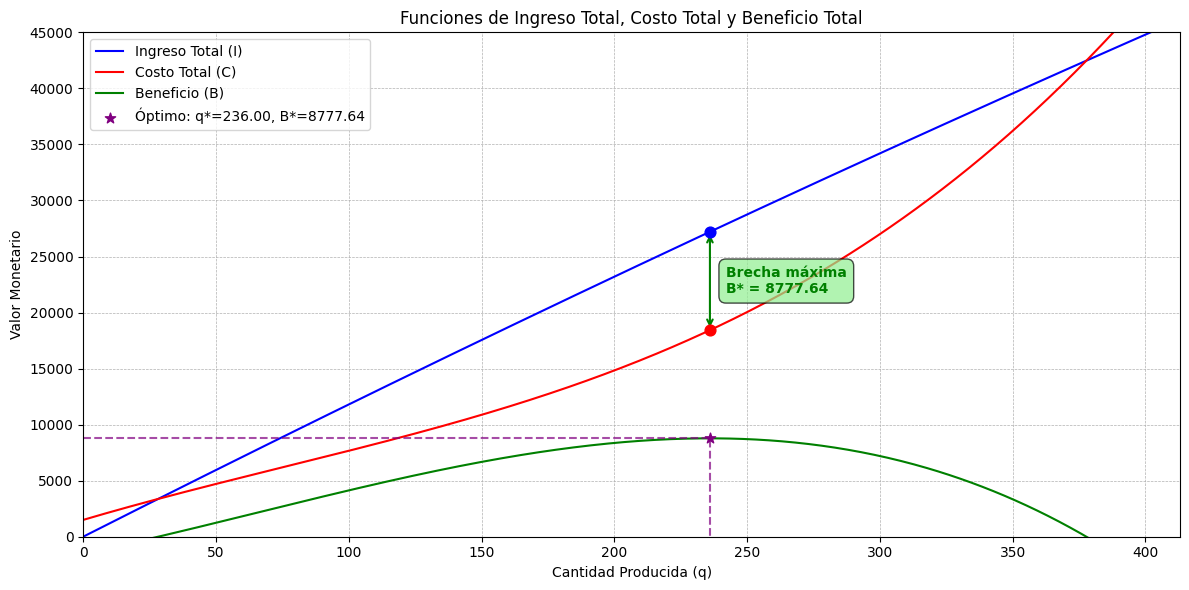

In [656]:
# Paso 4: Creo el gráfico
fig, axs = plt.subplots(figsize=(12, 6))


# Grafico las funciones
axs.plot(q_grid, I_vals, label='Ingreso Total (I)', color='blue')
axs.plot(q_grid, C_vals, label='Costo Total (C)', color='red')
axs.plot(q_grid, B_vals, label='Beneficio (B)', color='green')

# Marco el punto óptimo
axs.scatter(q_opt, B_opt, color='purple', s=60, label=f'Óptimo: q*={q_opt:.2f}, B*={B_opt:.2f}', marker='*', zorder=5)
axs.scatter(q_opt, I_opt, color='blue', s=60, zorder=4, marker='o')
axs.scatter(q_opt, C_opt, color='red', s=60, zorder=4, marker='o')

# Líneas de referencias
axs.vlines(x=q_opt, ymin=axs.get_ylim()[0], ymax=B_opt, color='purple', linestyle='--', alpha=0.7)
axs.hlines(y=B_opt, xmin=axs.get_xlim()[0], xmax=q_opt, color='purple', linestyle='--', alpha=0.7)

# Flecha bidireccional mostrando la distancia máxima (beneficio)
axs.annotate('', 
            xy=(q_opt, I_opt), 
            xytext=(q_opt, C_opt),
            arrowprops=dict(arrowstyle='<->', color='green', lw=1.5))

# Etiqueta explicativa de la brecha
axs.text(q_opt + 6, (I_opt + C_opt) / 2.1, 
        f'Brecha máxima\nB* = {B_opt:.2f}', 
        fontsize=10, color='green', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))

# Configuro Gráfico
axs.grid(True, which='both', linestyle='--', linewidth=0.5)
axs.set_title('Funciones de Ingreso Total, Costo Total y Beneficio Total')
axs.set_xlabel('Cantidad Producida (q)')
axs.set_ylabel('Valor Monetario')
axs.set_xlim(0, x_max)
axs.set_ylim(0, y_max)
axs.legend()

plt.tight_layout()
plt.show()

**Interpretación Económica del Gráfico:**

**1. Zona de Beneficios Crecientes (q < 236 unidades):**

Cuando la empresa produce menos de 236 unidades, el ingreso marginal supera al costo marginal (IMg > CMg). Esto significa que cada unidad adicional producida aporta más ingresos que costos, incrementando el beneficio total. En este rango, el incentivo económico de la empresa es **expandir la producción** hacia el punto óptimo.

**2. Punto de Maximización del Beneficio (q* = 236 unidades):**

En q* = 236 unidades se alcanza el **equilibrio de maximización** donde IMg = CMg. En este punto:
- Ingreso Total: I(236) = $27,206.08
- Costo Total: C(236) = $18,428.44
- **Beneficio Máximo: B* = $8,777.64**

Este es el nivel óptimo de producción que maximiza el beneficio económico de la empresa. Producir exactamente 236 unidades genera la mayor diferencia posible entre ingresos y costos.

**3. Zona de Beneficios Decrecientes (q > 236 unidades):**
Para cantidades superiores a 236 unidades, el costo marginal supera al ingreso marginal (CMg > IMg). Cada unidad adicional producida reduce el beneficio total, ya que los costos crecen más rápido que los ingresos. El incentivo económico en esta zona es **reducir la producción** hacia el punto óptimo.

**4. Rango de Operación Viable:**

El gráfico muestra que la empresa genera beneficios positivos (B(q) > 0) en el intervalo donde la curva de Ingreso Total está por encima de la curva de Costo Total. Los puntos de quiebre (donde B(q) = 0) marcan el **rango operacional mínimo** dentro del cual la empresa puede subsistir sin generar pérdidas. Operar fuera de este rango implica beneficios negativos (pérdidas).

**Conclusión:**

La empresa debe producir exactamente **236 unidades** para maximizar su beneficio en **$8,777.64**. Este análisis demuestra la importancia de igualar el ingreso marginal al costo marginal (condición de primer orden) para alcanzar la eficiencia económica en la producción.

---

# Ejercicio 2

---

Las funciones de oferta y demanda de cierto producto están dadas por:

$$O: p=20+3q$$

$$D:p= 100-q^2$$


1-Determinar el excedente del consumidor y del productor

2-Graficar ambas funciones en un mismo gráfico, donde el eje vertical debe ser el precio y el horizontal la cantidad.

3-Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor e interpretar

### 1. Determinar el excedente del consumidor y del productor


In [657]:
# Planteo y validación
# Las funciones de oferta y demanda ya se encuentran planteadas como funciones inversas
# de precio en función de cantidad. Por lo tanto, no es necesario realizar modificaciones
# adicionales como funciones inversas.

In [658]:
# Paso 1 Defino las variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)
p, q

(p, q)

In [659]:
# Paso 2 Defino la función de oferta 
P_s = 30.0 + 3.0*q
P_s

3.0*q + 30.0

In [660]:
# Paso 3 Defino la función de demanda
P_d = 100.0 - q**2
P_d

100.0 - q**2

In [661]:
# Paso 4 Encuentro cantidad óptima q* de equilibrio de mercado P_s(q) = P_d(q)
q_eq = sp.Eq(P_d, P_s)
q_eq = sp.solve(q_eq, q)
q_eq = round(q_eq[0])
q_eq

7

In [662]:
# Paso 5 Encuentro precio de equilibrio
p_eq = P_s.subs(q, q_eq)
p_eq

51.0000000000000

In [663]:
print("EQUILIBRIO DEL MERCADO:")
print(f"  Ecuación: {P_d} = {P_s}")
print(f"  q* = {q_eq}")
print(f"  p* = {p_eq:.2f}")

EQUILIBRIO DEL MERCADO:
  Ecuación: 100.0 - q**2 = 3.0*q + 30.0
  q* = 7
  p* = 51.00


In [664]:
# Paso 6 Excedente del Consumidor y del Productor
# Calculo con antiderivada y barrow para hallar EC y EP

print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq:.2f}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq:.2f} - P_s(q)] dq")

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 7] [P_d(q) - 51.00] dq
  • EP = ∫[0, 7] [51.00 - P_s(q)] dq


In [665]:
# Paso 7 Excedente del Consumidor (EC)
EC = sp.integrate(P_d - p_eq, (q, 0, q_eq))

print('''
EC: Es el beneficio que obtienen los consumidores por pagar un precio menor
al que estaban dispuestos a pagar.
''')
print(f"EC = {EC:.2f}")


EC: Es el beneficio que obtienen los consumidores por pagar un precio menor
al que estaban dispuestos a pagar.

EC = 228.67


In [666]:
# Paso 8 Excedente del Productor (EP)
EP = sp.integrate(p_eq - P_s, (q,0, q_eq))

print('''
EP: Es el beneficio que obtienen los productores por vender a un precio mayor
al que estaban dispuestos a vender.
''')
print(f"EP = {EP:.2f}")


EP: Es el beneficio que obtienen los productores por vender a un precio mayor
al que estaban dispuestos a vender.

EP = 73.50


In [667]:
# Paso 9 Excedente Total (ET)
ET = EC + EP # type: ignore

print('''
ET: Es la suma del beneficio que obtienen los consumidores y los productores,
representando el bienestar total generado por el mercado.
''')
print(f"ET = EC + EP = {ET:.2f}")


ET: Es la suma del beneficio que obtienen los consumidores y los productores,
representando el bienestar total generado por el mercado.

ET = EC + EP = 302.17


### 2. Graficar ambas funciones en un mismo gráfico, donde el eje vertical debe ser el precio y el horizontal la cantidad.


In [668]:
# Paso 1: Creo dominio y variables
# Valor máximo en el eje x para mejor visualización
x_max = q_eq
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

# Dominio del eje 'X'
q_grid = np.linspace(0, x_max, 500)

In [669]:
# Paso 2: Convierto funciones simbólicas a numéricas
P_d_num = sp.lambdify(q, P_d, 'numpy')
P_s_num = sp.lambdify(q, P_s, 'numpy')

In [670]:
# Preparo datos para graficar
P_d_vals = P_d_num(q_grid)
P_s_vals = P_s_num(q_grid)

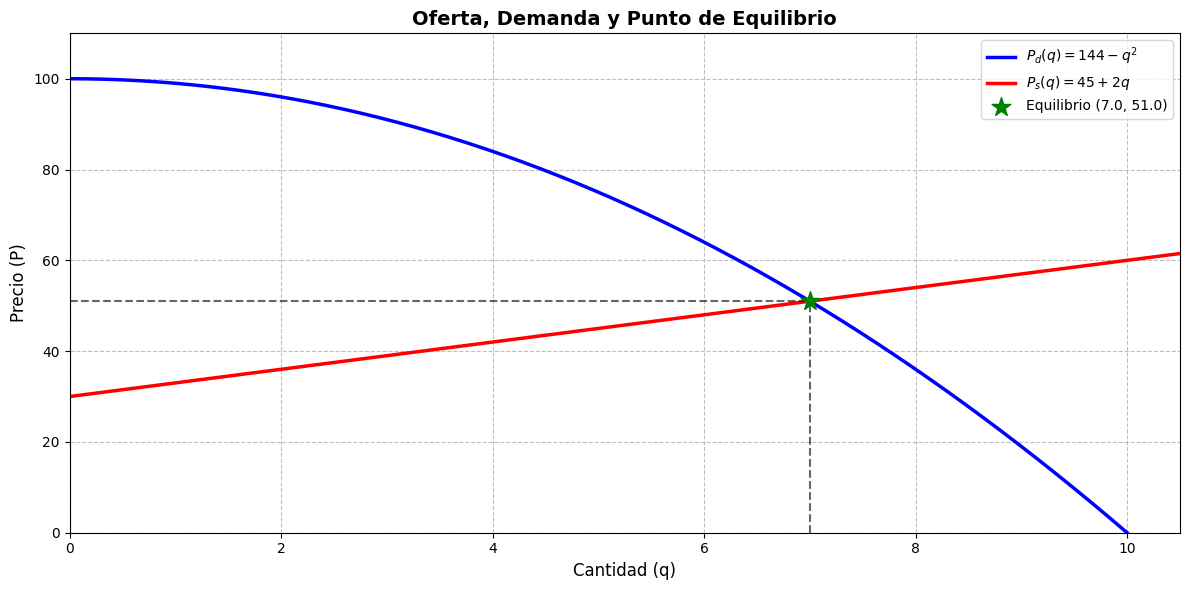

In [671]:
# Creo el Gráfico
plt.figure(figsize=(12, 6))
plt.plot(q_grid, P_d_vals, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, P_s_vals, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=200, c='green', marker='*', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})') # type: ignore
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='black', alpha=0.6) # type: ignore
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='black', alpha=0.6) # type: ignore

plt.title('Oferta, Demanda y Punto de Equilibrio', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

### 3. Sombrear las áreas correspondientes a los excedentes encontrados indicando en el gráfico cuál es el excedente del consumidor y cuál el del productor e interpretar

In [672]:
# Paso 1 Preparo los datos para graficar

# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_eq)) # type: ignore
x_max = x_y_max (x_max, 1.5, 'x')

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y')

q_grid = np.linspace(0, x_max, 500)


In [673]:
P_d_num = sp.lambdify(q, P_d, 'numpy')
P_s_num = sp.lambdify(q, P_s, 'numpy')

P_d_vals = P_d_num(q_grid)
P_s_vals = P_s_num(q_grid)


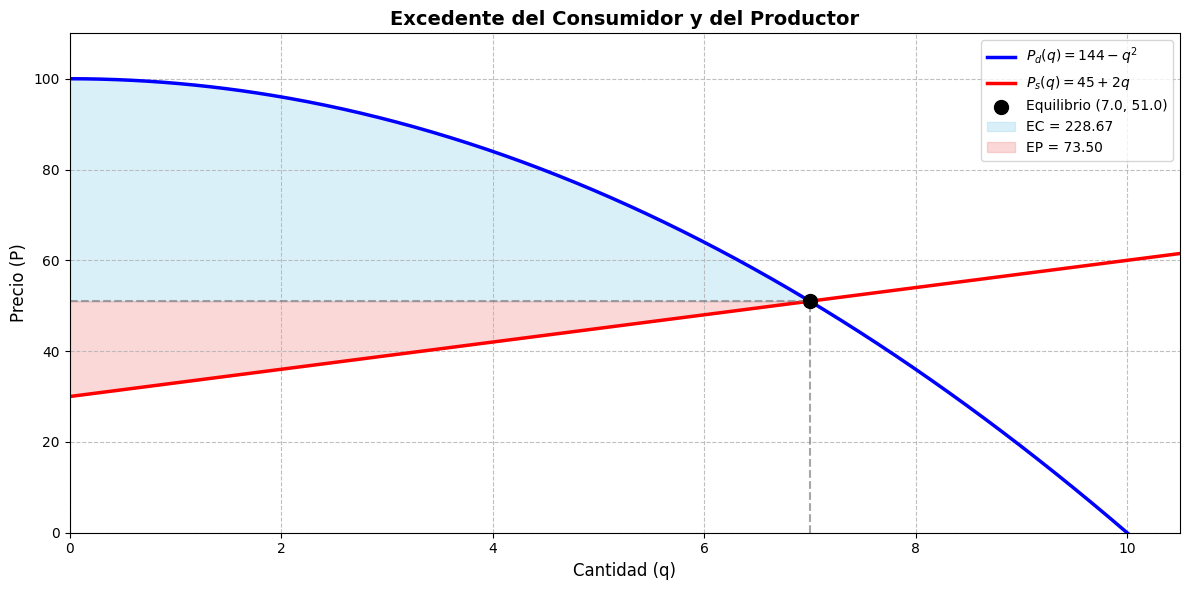

In [674]:
# Creo Gráfico
plt.figure(figsize=(12, 6))
plt.plot(q_grid, P_d_vals, label='$P_d(q) = 144 - q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, P_s_vals, label='$P_s(q) = 45 + 2q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=100, c='black', zorder=5, label=f'Equilibrio ({float(q_eq):.1f}, {float(p_eq):.1f})') # type: ignore
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, P_d_vals, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC):.2f}') # type: ignore
plt.fill_between(q_grid, float(p_eq), P_s_vals, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP):.2f}') # type: ignore

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.tight_layout()
plt.show()

**Interpretación:**

**Excedente del Consumidor (EC = 228,67):** Representa el beneficio neto que obtienen los consumidores al comprar el bien a un precio de equilibrio de $51, en lugar del precio máximo que estarían dispuestos a pagar según la curva de demanda $P_d(q) = 100 - q^2$. Este ahorro de $228,67 refleja la diferencia entre la valoración subjetiva del bien y el precio de mercado.

**Excedente del Productor (EP = 73,50):** Refleja el beneficio adicional que reciben los productores al vender a $51 por unidad, superando el precio mínimo que aceptarían según su curva de oferta $P_s(q) = 30 + 3q$. Este excedente de $73,50 representa la ganancia por encima de sus costos marginales de producción.

**Excedente Total (ET = 302,17):** La suma de ambos excedentes ($228,67 + $73,50 = $302,17) mide el bienestar social total generado por el mercado cuando opera en equilibrio. Este valor representa la eficiencia económica alcanzada cuando se intercambian 7 unidades al precio de $51.

**Conclusión:** El análisis muestra que el excedente del consumidor es aproximadamente 3 veces mayor que el excedente del productor (228,67/73,50 ≈ 3.11). Esto indica que, en esta configuración de mercado, los consumidores capturan la mayor porción del bienestar generado por el intercambio. La estructura particular de las funciones de oferta y demanda (demanda cóncava vs. oferta lineal) favorece significativamente a los compradores, quienes obtienen el 75.7% del excedente total mientras que los productores retienen solo el 24.3%.

---

## Ejercicio 3

---

Dada la función de Costo marginal

$$Cmg=0.02-300/x^2$$

1- Hallar la función de Costo total.

2- Calcular el costo total de producir 80 unidades si el costo fijo asciende a F=70

3- Calcular, a través de una integral definida, el costo total variable acumulado entre 20 y 35 unidades

4- Graficar costo total y costo marginal. Interpretar el gráfico.

### 1. Hallar la función de Costo total.



In [675]:
# Integro para hallar la función de Costo Total
# Paso 1: Defino las variables simbólicas
q = sp.symbols('q', positive=True)
F = sp.symbols('F')
q, F

(q, F)

In [676]:
# Paso 2: Defino la función de Costo Marginal
CMg = 0.02 - (300.0 / q**2)
CMg

0.02 - 300.0/q**2

In [677]:
# Paso 3: Integro la función de Ingreso Marginal para obtener la función de Ingreso Total
C = sp.integrate(CMg, q) + F
C = sp.simplify(C)
C

F + 0.02*q + 300.0/q

In [678]:
# Paso 4: Sustituyo F en la función de Costo Total
C = C.subs(F, 70.0)
C = C.simplify()
C

0.02*q + 70.0 + 300.0/q

### 2. Calcular el costo total de producir 80 unidades si el costo fijo asciende a F=70

In [679]:
# Sustituyo q = 80 en la función de Costo Total
C_80 = C.subs(q, 80.0)
print(f"""
El costo de producir 80 unidades con un
costo fijo de 70,0 unidades monetarias es
C(80) = {C_80:.2f}
      """)


El costo de producir 80 unidades con un
costo fijo de 70,0 unidades monetarias es
C(80) = 75.35
      


### 3. Calcular, a través de una integral definida, el costo total variable acumulado entre 20 y 35 unidades


In [680]:
# Costo acumulado entre 30 y 45 unidades
C_acum = sp.integrate(CMg, (q, 20, 35))
C_acum = round(C_acum, 2)

In [681]:
print(f"""
El costo total variable acumulado entre 20 y 35 unidades es de
{C_acum:.2f}
      """)


El costo total variable acumulado entre 20 y 35 unidades es de
-6.13
      


### 4. Graficar costo total y costo marginal. Interpretar el gráfico.

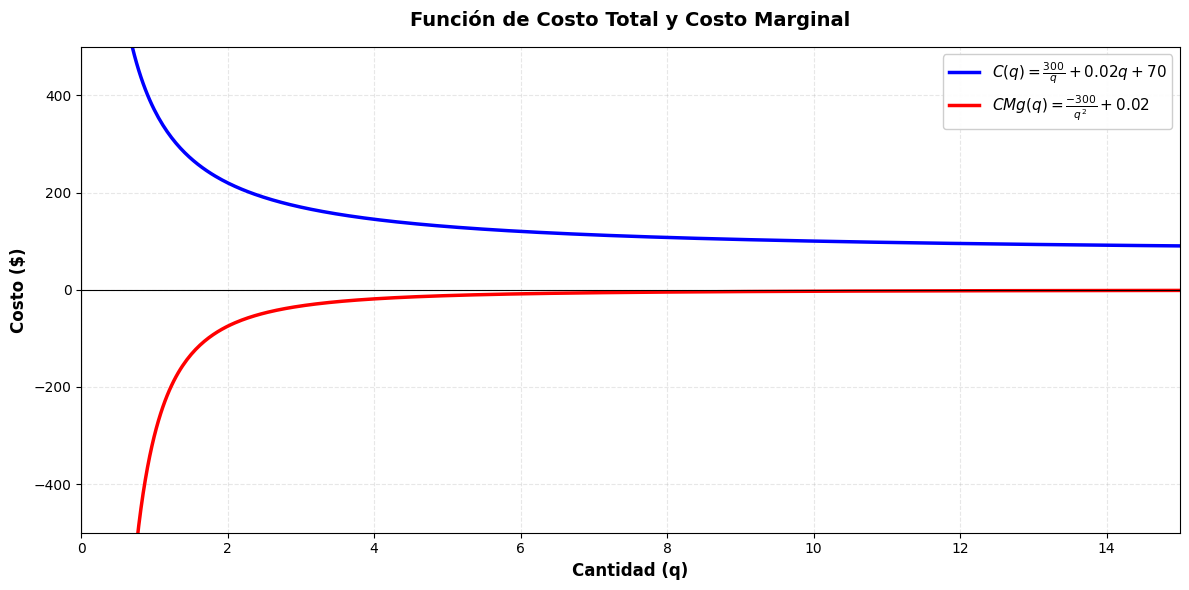

In [682]:
# Preparar datos para graficar
x_max = 15
q_grid = np.linspace(0.1, x_max, 500)
C_num = sp.lambdify(q, C)(q_grid)
CMg_num = sp.lambdify(q, CMg)(q_grid)

# Crear figura con tamaño adecuado
plt.figure(figsize=(12, 6))

# Graficar costo total y costo marginal
plt.plot(q_grid, C_num, label='$C(q) = \\frac{300}{q} + 0.02q + 70$', 
         linewidth=2.5, color='blue')
plt.plot(q_grid, CMg_num, label='$CMg(q) = \\frac{-300}{q^2} + 0.02$', 
         linewidth=2.5, color='red')

# Líneas de referencia
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Configuración del gráfico
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('Cantidad (q)', fontsize=12, fontweight='bold')
plt.ylabel('Costo ($)', fontsize=12, fontweight='bold')
plt.title('Función de Costo Total y Costo Marginal', 
         fontsize=14, fontweight='bold', pad=15)
plt.legend(fontsize=11, loc='upper right', framealpha=0.95)
plt.xlim(0, x_max)
plt.ylim(-500, 500)

plt.tight_layout()
plt.show()

**Interpretación Económica del Gráfico:**

**1. Comportamiento del Costo Marginal CMg(q):**

La función de costo marginal $CMg(q) = 0.02 - \frac{300}{q^2}$ presenta dos zonas claramente diferenciadas:

- **Zona de Costos Marginales Negativos (q < 12.25 unidades):** En este rango, el costo marginal es negativo, lo que significa que cada unidad adicional producida **reduce el costo total**. Este comportamiento atípico refleja fuertes **economías de escala** donde los costos fijos ($70) se distribuyen entre más unidades, generando eficiencias significativas.

- **Zona de Costos Marginales Positivos (q > 12.25 unidades):** A partir de q ≈ 12.25, el costo marginal se vuelve positivo, indicando que producir unidades adicionales incrementa el costo total. Sin embargo, el CMg tiende asintóticamente a $0.02, estabilizándose en un costo prácticamente constante para grandes volúmenes de producción.

**2. Punto Crítico de Minimización del Costo Total:**

El **punto mínimo de la función de costo total C(q)** ocurre donde **CMg(q) = 0**, aproximadamente en **q ≈ 12.25 unidades**. En este punto:

$$CMg(12.25) = 0.02 - \frac{300}{12.25^2} \approx 0$$

Este es el nivel de producción más eficiente desde la perspectiva del costo unitario, donde la empresa aprovecha al máximo las economías de escala antes de que los costos variables comiencen a incrementar el costo total.

**3. Comportamiento Asintótico del Costo Total:**

Para grandes cantidades (q > 50), la función de costo total se aproxima a:

$$C(q) \approx 0.02q + 70$$

Esto indica que el costo total crece **linealmente** con una pendiente muy pequeña ($0.02), reflejando que el componente variable del costo es prácticamente constante. Para q = 80 unidades:

$$C(80) = \$75.35$$

El costo fijo de $70 representa el **92.9%** del costo total, dominando la estructura de costos incluso para volúmenes considerables.

**4. Costo Variable Acumulado entre 20 y 35 unidades:**

Mediante integración definida:

$$\int_{20}^{35} CMg(q) \, dq = -6.13$$
Este resultado **negativo** confirma que en este rango específico, incrementar la producción de 20 a 35 unidades **reduce el costo total** debido a que el costo marginal promedio es negativo en ese intervalo.

**Conclusión:**

La estructura de costos presenta una característica inusual donde **aumentar la producción inicial reduce el costo total** hasta aproximadamente 12.25 unidades, punto a partir del cual el costo comienza a crecer de manera lineal y muy gradual. Esta configuración sugiere que la empresa debe operar a escalas superiores a 12.25 unidades para minimizar sus costos unitarios, y que los **costos fijos dominan la estructura económica** del negocio.

---

### Ejercicio 4

---

A partir del cash flow MENSUAL establecido en la línea de código propuesta a continuación y considerando un costo de capital anual del 10% ,realice un análisis que contenga:

1- Métricas financieras: VAN, TIR, TIRM y PAYBACK DESCONTADO e interprete cada una de ellas.

2- Grafique el flujo de fondos

3- Grafique el Van a diferentes tasas de descuento de costo del capital (marque en dicho gráfico la TIR y explíquelo)

4- Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 15% anual. Realice el análisis nuevamente e interprete los resultados.

5- Haga un gráfico comparativo de ambas situaciones

In [683]:
inversion_inicial = -60000
cash_flows = [
    12000, -10000, 18000, 20000, 25000, 23000, 28000, 30000, -25000, 35000,
    -7000, 12000, 15000, 18000, -20000, 22000, -26000, 29000, -20000, 35000,
    -9000, 13000, -16000, 19000, 22000, 25000, 28000, -28000, 35000
]
nuevo_cash_flow = [inversion_inicial] + cash_flows


### 1. Métricas financieras: VAN, TIR, TIRM y PAYBACK DESCONTADO e interprete cada una de ellas.

In [684]:
# Tasa de descuento anual
TEA = 0.10  # 10% anual

# Definir la tasa de descuento mensual
r = tasa_equivalente(TEA, 30, 365) # La fórmula está al inicio de esta notebook
print(f"Tasa efectiva mensual equivalente: TEA {TEA:.2%} → TEM {r:.4%}")

Tasa efectiva mensual equivalente: TEA 10.00% → TEM 0.7864%


In [685]:
# VAN
van = nf.npv(r, nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r:.4%}")
print(f"El proyecto genera un valor actual neto de ${van:,.2f}.")

Tasa de descuento mensual utilizada: 0.7864%
El proyecto genera un valor actual neto de $211,914.79.


**Interpretación:** El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa, ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial. Segun el VAN el proyecto es rentable

In [686]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)
tir_anual = tasa_equivalente(tir, 365, 30)

print(f"TIR mensual: {tir:.2%}")
print(f"TEM: {r:.2%}")
print(f"TIR anual: {tir_anual:.2%}")
print(f'VIABLE: La TIR ({tir_anual:.2%}) supera el costo de capital ({TEA:.2%}).')

TIR mensual: 20.16%
TEM: 0.79%
TIR anual: 834.08%
VIABLE: La TIR (834.08%) supera el costo de capital (10.00%).


**Interpretacion:** La TIR (mensual) es mucho mayor que la tasa de descuento (mensual) (20.16% > 0,79%). Esto significa que la rentabilidad intrínseca del proyecto está muy por encima del rendimiento mínimo exigido. Segun el TIR el proyecto es rentable

In [687]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital)
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad)
tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=tir, reinvest_rate=r)
tirm_anual = tasa_equivalente(tirm, 365, 30)

print(f"TIRM mensual: {tirm:.4%}")
print(f"TEM: {r:.2%}")
print(f"TIRM anual: {tirm_anual:.2%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.2%} anual.")
print(f"Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f'VIABLE: La TIRM ({tirm_anual:.2%}) supera el costo de capital ({TEA:.2%}).')

TIRM mensual: 6.8295%
TEM: 0.79%
TIRM anual: 123.40%

Interpretación: La rentabilidad modificada es 123.40% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
VIABLE: La TIRM (123.40%) supera el costo de capital (10.00%).


**Interpretacion:** La TIRM mensual es mayor que la tasa de descuento mensual (6,83%>0,79%). Esto indica que la rentabilidad efectiva del proyecto, asumiendo que tanto los flujos de caja positivos se reinvierten a una tasa de reinversion como que los flujos de caja negativos se financian a una tasa de financiamiento, supera al costo de capital. *Segun el TIRM el proyecto es rentable*.

In [688]:
# Período de Recuperación Descontado (PRD) - Fórmula corregida
prd = payback_desc(nuevo_cash_flow, r) # La fórmula está al inicio de esta notebook
print(f"Payback descontado: {prd:.2f} meses ({prd/12:.2f} años)" if prd is not None else "📊 Payback descontado: No se recupera la inversión")

Payback descontado: 4.87 meses (0.41 años)


**Interpretación del Período de Recuperación Descontado (PRD):**

El PRD indica que la **inversión inicial de $60,000** se recupera en **4.87 meses** cuando se consideran los flujos de caja descontados a la tasa mensual del 0.79%.

**Análisis:**

- **Tiempo de recuperación:** 4.87 meses (aproximadamente 5 meses)
- **Criterio de aceptación:** PRD < 24 meses → **Proyecto viable**
- **Interpretación:** Un PRD corto (5 meses) indica **bajo riesgo temporal**, ya que la inversión se recupera rápidamente, reduciendo la exposición a incertidumbres futuras.

**Conclusión:**

La empresa recupera su inversión inicial en menos de 5 meses, lo que confirma que el proyecto es seguro desde la perspectiva de liquidez y rentabilidad temporal.

### 2. Grafique el flujo de fondos


### 3. Grafique el Van a diferentes tasas de descuento de costo del capital (marque en dicho gráfico la TIR y explíquelo)


### 4. Considere que el gerente financiero pronostica un aumento posible del costo de capital a la hora de iniciar el proyecto conformando un costo total del 15% anual. Realice el análisis nuevamente e interprete los resultados.


### 5. Haga un gráfico comparativo de ambas situaciones



---


###Ejercicio 5

---
Corra la siguiente celda, que genera el dataset df_supermarket.csv

Usted recibe estos datos y debe formular un informe de evolución de ventas y situación para el equipo directivo. Arme gráficas y genere dicho informe para explicar el desempeño del supermercado durante el 2024.


In [689]:
# Generación de un CSV de ejemplo para el Ejercicio 5 Adicional (Ventas de Supermercado)
import pandas as pd
import numpy as np

# Crear datos ficticios para un archivo Supermarket_Sales.csv
np.random.seed(42) # para reproducibilidad

productos = ['Leche', 'Yogur', 'Queso', 'Carne Res', 'Pollo', 'Pescado', 'Manzanas', 'Bananas', 'Lechuga', 'Pan Blanco', 'Galletas']
categorias = ['Lácteos', 'Lácteos', 'Lácteos', 'Carnes', 'Carnes', 'Carnes', 'Frutas y Verduras', 'Frutas y Verduras', 'Frutas y Verduras', 'Panadería', 'Panadería']
regiones = ['Norte', 'Sur', 'Este', 'Oeste']

data = {
    'nombre_producto': np.random.choice(productos, 1000),
    'categoria': np.random.choice(categorias, 1000),
    'fecha_venta': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 365, 1000), unit='D'),
    'unidades_vendidas_diarias': np.random.randint(10, 200, 1000),
    'precio_unitario': np.round(np.random.uniform(1.5, 50, 1000), 2),
    'costo_unitario': np.round(np.random.uniform(0.5, 30, 1000), 2),
    'region': np.random.choice(regiones, 1000)
}
df_supermarket = pd.DataFrame(data)

df_supermarket['ingreso_bruto_diario'] = df_supermarket['unidades_vendidas_diarias'] * df_supermarket['precio_unitario']
df_supermarket['margen_ganancia_bruto'] = (df_supermarket['precio_unitario'] - df_supermarket['costo_unitario']) * df_supermarket['unidades_vendidas_diarias']
df_supermarket['margen_ganancia_porcentual'] = (df_supermarket['margen_ganancia_bruto'] / df_supermarket['ingreso_bruto_diario']).fillna(0) # Handle division by zero if ingreso_bruto_diario is 0


df_supermarket['cambio_ventas_semanal'] = np.round(np.random.uniform(-15, 20, 1000), 2) # % de cambio
df_supermarket


,nombre_producto,categoria,fecha_venta,unidades_vendidas_diarias,precio_unitario,costo_unitario,region,ingreso_bruto_diario,margen_ganancia_bruto,margen_ganancia_porcentual,cambio_ventas_semanal
0,Manzanas,Frutas y Verduras,2024-05-26,10,24.82,11.74,Sur,248.20,130.80,0.526994,-5.94
1,Carne Res,Frutas y Verduras,2024-10-13,96,33.63,24.35,Sur,3228.48,890.88,0.275944,-3.92
2,Galletas,Lácteos,2024-05-21,137,7.25,24.80,Oeste,993.25,-2404.35,-2.420690,-11.96
3,Bananas,Carnes,2024-02-22,76,15.51,11.85,Norte,1178.76,278.16,0.235977,-4.39
4,Pollo,Lácteos,2024-10-30,13,20.80,14.04,Oeste,270.40,87.88,0.325000,18.83
...,...,...,...,...,...,...,...,...,...,...,...
995,Pan Blanco,Frutas y Verduras,2024-06-04,31,5.61,5.22,Norte,173.91,12.09,0.069519,-8.23
996,Lechuga,Frutas y Verduras,2024-02-16,110,24.13,20.89,Este,2654.30,356.40,0.134273,18.28
997,Yogur,Carnes,2024-07-19,164,24.88,5.44,Norte,4080.32,3188.16,0.781350,-0.70
998,Bananas,Lácteos,2024-05-27,130,42.28,9.65,Sur,5496.40,4241.90,0.771760,1.33
